CZĘŚĆ 1: Wprowadzenie i opis problemu, opis zbioru danych


Celem projektu jest analiza danych oraz budowa modeli predykcyjnych służących do przewidywania poziomu dochodu osoby na podstawie cech demograficznych i zawodowych. Zadanie to ma charakter klasyfikacji binarnej, w której zmienną docelową jest informacja, czy roczny dochód danej osoby przekracza 50 tysięcy dolarów.

Problem predykcji poziomu dochodu ma istotne znaczenie praktyczne, m.in. w analizach społeczno-ekonomicznych, systemach wsparcia decyzji oraz badaniach rynku pracy.


1.1 Opis zbioru danych
W projekcie wykorzystano zbiór danych Adult Income Dataset, który zawiera 48 842 rekordy.
Celem zbioru jest predykcja poziomu dochodu, określonego jako informacja, czy roczny dochód danej osoby przekracza 50 tysięcy dolarów amerykańskich.
Zmienna docelowa *income* jest zmienną binarną i przyjmuje wartości:
- `<=50K` – dochód nieprzekraczający 50 tysięcy dolarów,
- `>50K` – dochód przekraczający 50 tysięcy dolarów. 
Zbiór danych składa się z cech o zróżnicowanym charakterze – zarówno numerycznym, jak i kategorycznym.
Do zmiennych numerycznych należą m.in. wiek (*age*), liczba lat edukacji (*education-num*), zyski i straty kapitałowe (*capital-gain*, *capital-loss*) oraz liczba godzin pracy w tygodniu (*hours-per-week*).
Zmienne kategoryczne opisują m.in. rodzaj wykonywanej pracy (*workclass*), poziom wykształcenia (*education*), stan cywilny (*marital-status*), zawód (*occupation*), relacje rodzinne (*relationship*), rasę (*race*), płeć (*sex*) oraz kraj pochodzenia (*native-country*).
Fnlwgt to  techniczna zmienna, która służyła do ważenia danych w badaniu. Nie mówi nic o ludziach, tylko o metodzie zbierania danych, wię nie została uwzględniona.
Wiele z tych zmiennych posiada dużą liczbę kategorii, co wymaga odpowiedniego przetwarzania na dalszych etapach analizy.


In [116]:
import pandas as pd
import numpy as np

In [117]:
# Nazwy kolumn dla zbioru Adult
columns = [
    'age', 'workclass', 'fnlwgt', 'education', 'education-num', 'marital-status',
    'occupation', 'relationship', 'race', 'sex', 'capital-gain', 'capital-loss',
    'hours-per-week', 'native-country', 'income'
]


In [118]:
# Wczytanie zbioru treningowego
train_url = "https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data"
train_data = pd.read_csv(train_url, header=None, names=columns)

In [119]:
# Wczytanie zbioru testowego
test_url = "https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.test"
test_data = pd.read_csv(test_url, header=0, names=columns, skiprows=1)


In [120]:
#podgląd danych
train_data.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [121]:
# Informacje o zbiorze treningowym
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education-num   32561 non-null  int64 
 5   marital-status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital-gain    32561 non-null  int64 
 11  capital-loss    32561 non-null  int64 
 12  hours-per-week  32561 non-null  int64 
 13  native-country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


Jednakowa liczba niepustych obserwacji dla wszystkich kolumn wskazuje na to, że w zbiorze nie ma braków danych.
Ale braki danych w zbiorze Adult są oznaczone symbolem „?”, który nie jest traktowany jako NaN przez Pandas, dlatego konieczna była ich ręczna identyfikacja i obsługa.

In [123]:
# Rozmiar zbioru treningowego
train_data.shape

(32561, 15)

In [124]:
# Statystyki zmiennych liczbowych
train_data.describe()

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
count,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,1.897784e+05,10.080679,1077.648844,87.303830,40.437456
std,13.640433,1.055500e+05,2.572720,7385.292085,402.960219,12.347429
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


W ramach wstępnego opisu danych obliczono podstawowe statystyki opisowe dla zmiennych numerycznych, obejmujące m.in. wartości średnie, mediany oraz zakres zmienności.
Analiza ta ma charakter poglądowy i służy ogólnemu zapoznaniu się z danymi przed przeprowadzeniem szczegółowej analizy eksploracyjnej.


In [126]:
# Liczność kategorii w zmiennych kategorycznych i numeryznych
categorical_cols = train_data.select_dtypes(include='object').columns
numeric_cols = train_data.select_dtypes(include=['int64','float64']).columns

In [127]:
for col in categorical_cols:
    print(train_data[col].value_counts())

workclass
Private             22696
Self-emp-not-inc     2541
Local-gov            2093
?                    1836
State-gov            1298
Self-emp-inc         1116
Federal-gov           960
Without-pay            14
Never-worked            7
Name: count, dtype: int64
education
HS-grad         10501
Some-college     7291
Bachelors        5355
Masters          1723
Assoc-voc        1382
11th             1175
Assoc-acdm       1067
10th              933
7th-8th           646
Prof-school       576
9th               514
12th              433
Doctorate         413
5th-6th           333
1st-4th           168
Preschool          51
Name: count, dtype: int64
marital-status
Married-civ-spouse       14976
Never-married            10683
Divorced                  4443
Separated                 1025
Widowed                    993
Married-spouse-absent      418
Married-AF-spouse           23
Name: count, dtype: int64
occupation
Prof-specialty       4140
Craft-repair         4099
Exec-managerial      

Można zauważyć wartosci ?, co wskazuje na braki, które zostaną obsłużone w 2 częsci analizy.

In [129]:
# Ustawienie zmiennej celu
target_column = 'income'
target_column

'income'

CZESC 2: Czyszczenie i wstepne przetwarzanie danych

Celem tego etapu było przygotowanie danych do dalszej analizy eksploracyjnej oraz modelowania. Proces ten obejmuje identyfikację i obsługę braków danych, analizę i transformację wartości odstających, kodowanie zmiennych kategorycznych oraz standaryzację zmiennych numerycznych.

1) garbage data

In [132]:
# Wartości " ?" -> NaN
train_data.replace(' ?', np.nan, inplace=True)
test_data.replace(' ?', np.nan, inplace=True)

W zbiorze danych występowały wartości " ?" oznaczające brak informacji. Zostały one zamienione na standardowe NaN w celu ujednolicenia formatu braków danych w obu zbiorach treningowym i testowym.

In [134]:
# Usunięcie kropki w income w zbiorze testowym
test_data['income'] = test_data['income'].str.strip().str.replace('.', '', regex=False)

W zbiorze testowym zmienna income zawierała nieprawidłowy format z dodatkową kropką, np. "50K.". Usunięto zbędne znaki interpunkcyjne, aby zapewnić spójność z formatem w zbiorze treningowym.

2) missing values

In [137]:
train_data.isnull().sum()

age                  0
workclass         1836
fnlwgt               0
education            0
education-num        0
marital-status       0
occupation        1843
relationship         0
race                 0
sex                  0
capital-gain         0
capital-loss         0
hours-per-week       0
native-country     583
income               0
dtype: int64

In [138]:
test_data.isnull().sum()

age                 0
workclass         963
fnlwgt              0
education           0
education-num       0
marital-status      0
occupation        966
relationship        0
race                0
sex                 0
capital-gain        0
capital-loss        0
hours-per-week      0
native-country    274
income              0
dtype: int64

Analiza wykazała braki danych w 3 kolumnach zbiorach:  workclass, occupation, native country.

3) Imputacja missing values

In [141]:
from sklearn.preprocessing import StandardScaler
from IPython.display import display


In [142]:
# Liczbowe kolumny -> wypełniamy medianą
for col in numeric_cols:
    train_data[col] = train_data[col].fillna(train_data[col].median())
    test_data[col] = test_data[col].fillna(test_data[col].median())

In [143]:
# Kategoryczne kolumny -> wypełniamy modą
for col in categorical_cols:
    train_data[col] = train_data[col].fillna(train_data[col].mode()[0])
    test_data[col] = test_data[col].fillna(test_data[col].mode()[0])

Dla zmiennych numerycznych zastosowano imputację medianą, która jest odporna na wartości odstające. Dla zmiennych kategorycznych zastosowano imputację modą (najczęściej występującą wartością).

4) duplicates 

In [146]:
train_data.duplicated().sum()

24

In [147]:
test_data.duplicated().sum()

5

W zbiorze treningowym znaleziono 24 zduplikowane obserwacje, a w testowym 5. Biorąc pod uwagę charakter danych i niewielki procent duplikatów względem całego zbioru, podjęto decyzję o zachowaniu duplikatów.

In [149]:
eda_data = train_data.copy()

5) Analiza wartosci odstajacych outliers i transformacja


In [151]:
num_cols = ['age', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']

Q1 = train_data[num_cols].quantile(0.25)
Q3 = train_data[num_cols].quantile(0.75)
IQR = Q3 - Q1

outliers = ((train_data[num_cols] < (Q1 - 1.5 * IQR)) | 
            (train_data[num_cols] > (Q3 + 1.5 * IQR)))

outliers.sum()

age                143
education-num     1198
capital-gain      2712
capital-loss      1519
hours-per-week    9008
dtype: int64

W zbiorze Adult ekstremalne wartości mają znaczenie ekonomiczne, a usuwanie tych obserwacji zmniejszyłoby zbiór lub mogłoby pogorszyć jakość modelu.

Analiza wartości odstających została przeprowadzona z wykorzystaniem metody IQR dla zmiennych numerycznych. Największą liczbę obserwacji odstających zidentyfikowano dla zmiennych capital-gain, capital-loss oraz hours-per-week, co wskazuje na silnie skośne rozkłady typowe dla danych ekonomicznych. Ze względu na potencjalną wartość informacyjną obserwacji ekstremalnych, zdecydowano się nie usuwać rekordów, lecz zastosować transformację logarytmiczną zmiennych capital-gain oraz capital-loss, co ogranicza wpływ wartości odstających na proces uczenia modeli.


In [153]:
#obsługa outliers - > transformacja log b
for col in ['capital-gain', 'capital-loss', 'hours-per-week']:
    train_data[col] = np.log1p(train_data[col])
    test_data[col] = np.log1p(test_data[col])

5)kodowanie zmiennych kategorycznych

In [155]:
train_data = pd.get_dummies(train_data, columns=categorical_cols.drop('income'), drop_first=True)

In [156]:
test_data = pd.get_dummies(test_data, columns=categorical_cols.drop('income'), drop_first=True)


Zmienne kategoryczne zakodowaliśmy metodą one-hot.

6)dopasowanie kolumn

In [159]:
train_data, test_data = train_data.align(test_data, join='left', axis=1, fill_value=0)

Po one-hot encodingu kolumny w train i test mogą się różnić (np. w train była kategoria, której nie ma w test).Funkcja align() ujednolica strukturę danych.nia

7)Przekształcenie zmiennej celu na binarny format numeryczny 0/1

In [162]:
train_data['income'] = train_data['income'].apply(lambda x: 1 if x.strip() == '>50K' else 0)
test_data['income'] = test_data['income'].apply(lambda x: 1 if x.strip() == '>50K' else 0)

8)Standaryzacja zmiennych liczbowych do średniej 0 i odchylenia 1

In [164]:
num_cols = train_data.select_dtypes(include=['int64','float64']).drop('income', axis=1).columns
scaler = StandardScaler()
train_data[num_cols] = scaler.fit_transform(train_data[num_cols])
test_data[num_cols] = scaler.transform(test_data[num_cols])

9)Zbiory po czyszczeniu

In [166]:
display(train_data.head())

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week,income,workclass_ Local-gov,workclass_ Never-worked,workclass_ Private,...,native-country_ Portugal,native-country_ Puerto-Rico,native-country_ Scotland,native-country_ South,native-country_ Taiwan,native-country_ Thailand,native-country_ Trinadad&Tobago,native-country_ United-States,native-country_ Vietnam,native-country_ Yugoslavia
0,0.030671,-1.063611,1.134739,2.831370,-0.221075,0.124560,0,False,False,False,...,False,False,False,False,False,False,False,True,False,False
1,0.837109,-1.008707,1.134739,-0.299271,-0.221075,-2.651904,0,False,False,False,...,False,False,False,False,False,False,False,True,False,False
2,-0.042642,0.245079,-0.420060,-0.299271,-0.221075,0.124560,0,False,False,True,...,False,False,False,False,False,False,False,True,False,False
3,1.057047,0.425801,-1.197459,-0.299271,-0.221075,0.124560,0,False,False,True,...,False,False,False,False,False,False,False,True,False,False
4,-0.775768,1.408176,1.134739,-0.299271,-0.221075,0.124560,0,False,False,True,...,False,False,False,False,False,False,False,False,False,False


In [167]:
display(test_data.head())

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week,income,workclass_ Local-gov,workclass_ Never-worked,workclass_ Private,...,native-country_ Portugal,native-country_ Puerto-Rico,native-country_ Scotland,native-country_ South,native-country_ Taiwan,native-country_ Thailand,native-country_ Trinadad&Tobago,native-country_ United-States,native-country_ Vietnam,native-country_ Yugoslavia
0,-0.042642,-0.947095,-0.420060,-0.299271,-0.221075,0.688510,0,False,False,True,...,False,False,False,False,False,False,False,True,False,False
1,-0.775768,1.394362,0.746039,-0.299271,-0.221075,0.124560,1,True,False,False,...,False,False,False,False,False,False,False,True,False,False
2,0.397233,-0.279070,-0.031360,3.345796,-0.221075,0.124560,1,False,False,True,...,False,False,False,False,False,False,False,True,False,False
3,-1.508894,-0.817458,-0.031360,-0.299271,-0.221075,-0.597866,0,False,False,True,...,False,False,False,False,False,False,False,True,False,False
4,-0.335892,0.084460,-1.586158,-0.299271,-0.221075,-0.597866,0,False,False,True,...,False,False,False,False,False,False,False,True,False,False


Po przeprowadzeniu czyszczenia i przetwarzania danych otrzymaliśmy spójne zbiory gotowe do modelowania, zawierające 98 cech. Ujemne wartości widoczne w zmiennych takich jak wiek czy liczba godzin pracy są efektem standaryzacji i oznaczają obserwacje poniżej średniej, a nie wartości rzeczywiste mniejsze od zera. Taka normalizacja poprawia skuteczność modeli uczenia maszynowego.

3. Analiza eksploracyjna danych (EDA)

Celem analizy eksploracyjnej danych było lepsze zrozumienie struktury zbioru danych oraz zależności pomiędzy zmienną docelową *income* a wybranymi zmiennymi objaśniającymi. Analiza ta pozwala na wstępne zidentyfikowanie cech, które mogą mieć istotny wpływ na wynik klasyfikacji.


3.1 Analiza opisowa danych

In [171]:
import seaborn as sns
import matplotlib.pyplot as plt

In [172]:
# Zmienne numeryczne
num_cols = ['age', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']

# Zmienne kategoryczne
cat_cols = ['workclass', 'education', 'marital-status', 'occupation', 
            'relationship', 'race', 'native-country']

# Zmienne binarne
bin_cols = ['sex', 'income']

# Podstawowe statystyki zmiennych numerycznych
eda_data[num_cols].describe()


,age,education-num,capital-gain,capital-loss,hours-per-week
count,32561.000000,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,10.080679,1077.648844,87.303830,40.437456
std,13.640433,2.572720,7385.292085,402.960219,12.347429
min,17.000000,1.000000,0.000000,0.000000,1.000000
25%,28.000000,9.000000,0.000000,0.000000,40.000000
50%,37.000000,10.000000,0.000000,0.000000,40.000000
75%,48.000000,12.000000,0.000000,0.000000,45.000000
max,90.000000,16.000000,99999.000000,4356.000000,99.000000


Najbardziej uderzający jest kontrast w zmiennych finansowych: 75% osób nie ma żadnych zysków kapitałowych (capital-gain = 0), ale średnia wynosi 1,078 USD – to efekt kilku ekstremalnych przypadków z zyskami do 99,999 USD. Podobny wzór dotyczy strat kapitałowych. To czysty obraz nierówności ekonomicznych w danych.

Godziny pracy są zaskakująco ustandaryzowane. Mediana to dokładnie 40 godzin (pełny etat), a 75% osób pracuje między 40-45 godzin tygodniowo, mimo ekstremów od 1 do 99 godzin.

Przeciętny respondent to 37-letnia osoba z wykształceniem średnim (poziom 10 w skali 1-16), pracująca na pełen etat, bez inwestycji kapitałowych. 

3.2 Rozkład zmiennej docelowej

Poniżej przedstawiono rozkład zmiennej docelowej *income*. Widoczna jest przewaga klasy oznaczającej dochód poniżej 50K, co wskazuje na niezbalansowany charakter problemu klasyfikacyjnego.


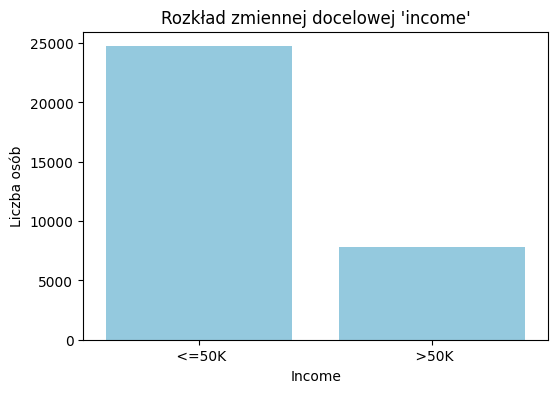

In [175]:
plt.figure(figsize=(6,4))
sns.countplot(x=eda_data['income'], color='skyblue') 
plt.title("Rozkład zmiennej docelowej 'income'")
plt.xlabel("Income")
plt.ylabel("Liczba osób")
plt.show()


In [176]:
eda_data['income'].value_counts()


income
<=50K    24720
>50K      7841
Name: count, dtype: int64

3.3 Zależności pomiędzy zmienną docelową a wybranymi cechami

W celu zbadania relacji pomiędzy zmienną docelową *income* a cechami numerycznymi wykorzystano wykresy pudełkowe.


3.Rozkłady zmiennych numerycznych

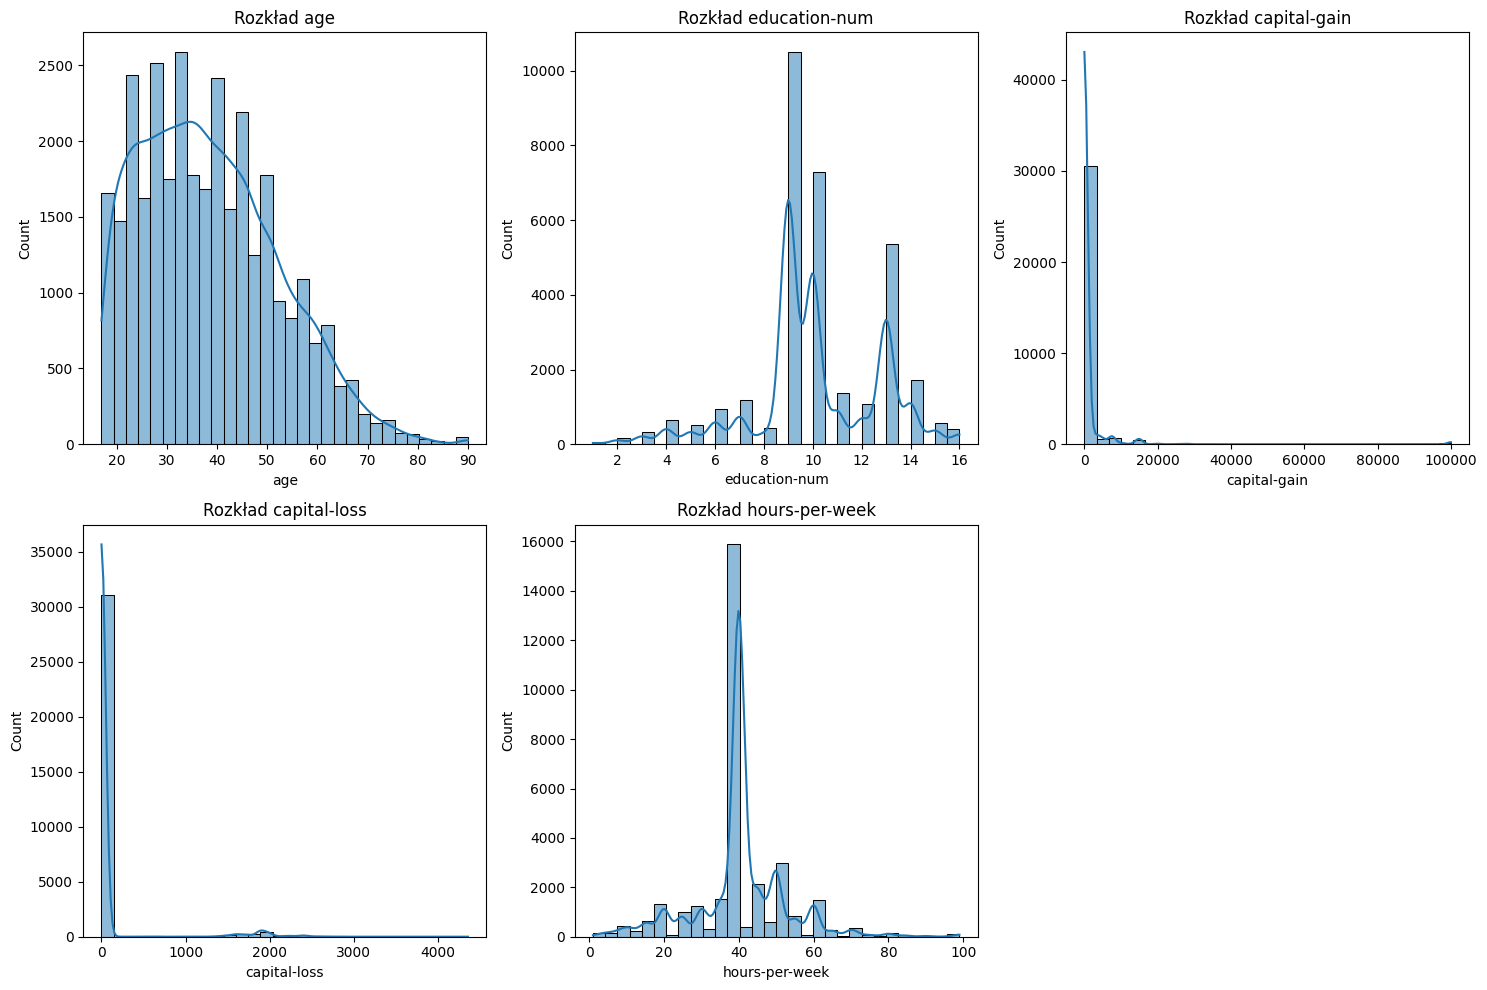

In [179]:
plt.figure(figsize=(15,10))
for i, col in enumerate(num_cols):
    plt.subplot(2,3,i+1)
    sns.histplot(eda_data[col], kde=True, bins=30)
    plt.title(f'Rozkład {col}')
plt.tight_layout()
plt.show()


Wiek: większość ludzi ma między 30 a 40 lat, czyli to głównie osoby w sile wieku, które pracują. Mało studentów czy emerytów.

Poziom wykształcenia: jedni skończyli tylko podstawówkę (niższe liczby), inni studia (wyższe liczby). Widać wyraźne 'górki' na wykresie - to znaczy, że ludzie często kończą edukację na podobnych etapach.

Pieniądze z inwestycji: 90% osób ma zero jeśli chodzi o zyski lub straty kapitałowe. To znaczy, że większość ludzi żyje z pracy, a nie z inwestycji. Tylko nieliczni mają akcje, nieruchomości itp.

Godziny pracy: wyiększość pracuje standardowe 40 godzin tygodniowo, ale spora grupa robi po 50 godzin. Są też nieliczni, którzy harają po 80-100 godzin, pewnie pracoholicy albo osoby pracujące na kilku etatach.

Podsumowując: Mamy do czynienia z typowymi pracującymi Amerykananinem w średnim wieku, pracujący na pełen etat (często z nadgodzinami), żyjący z pensji, a nie z inwestycji.

4.Rozkłady zmiennych kategorycznych i binernej "płeć"

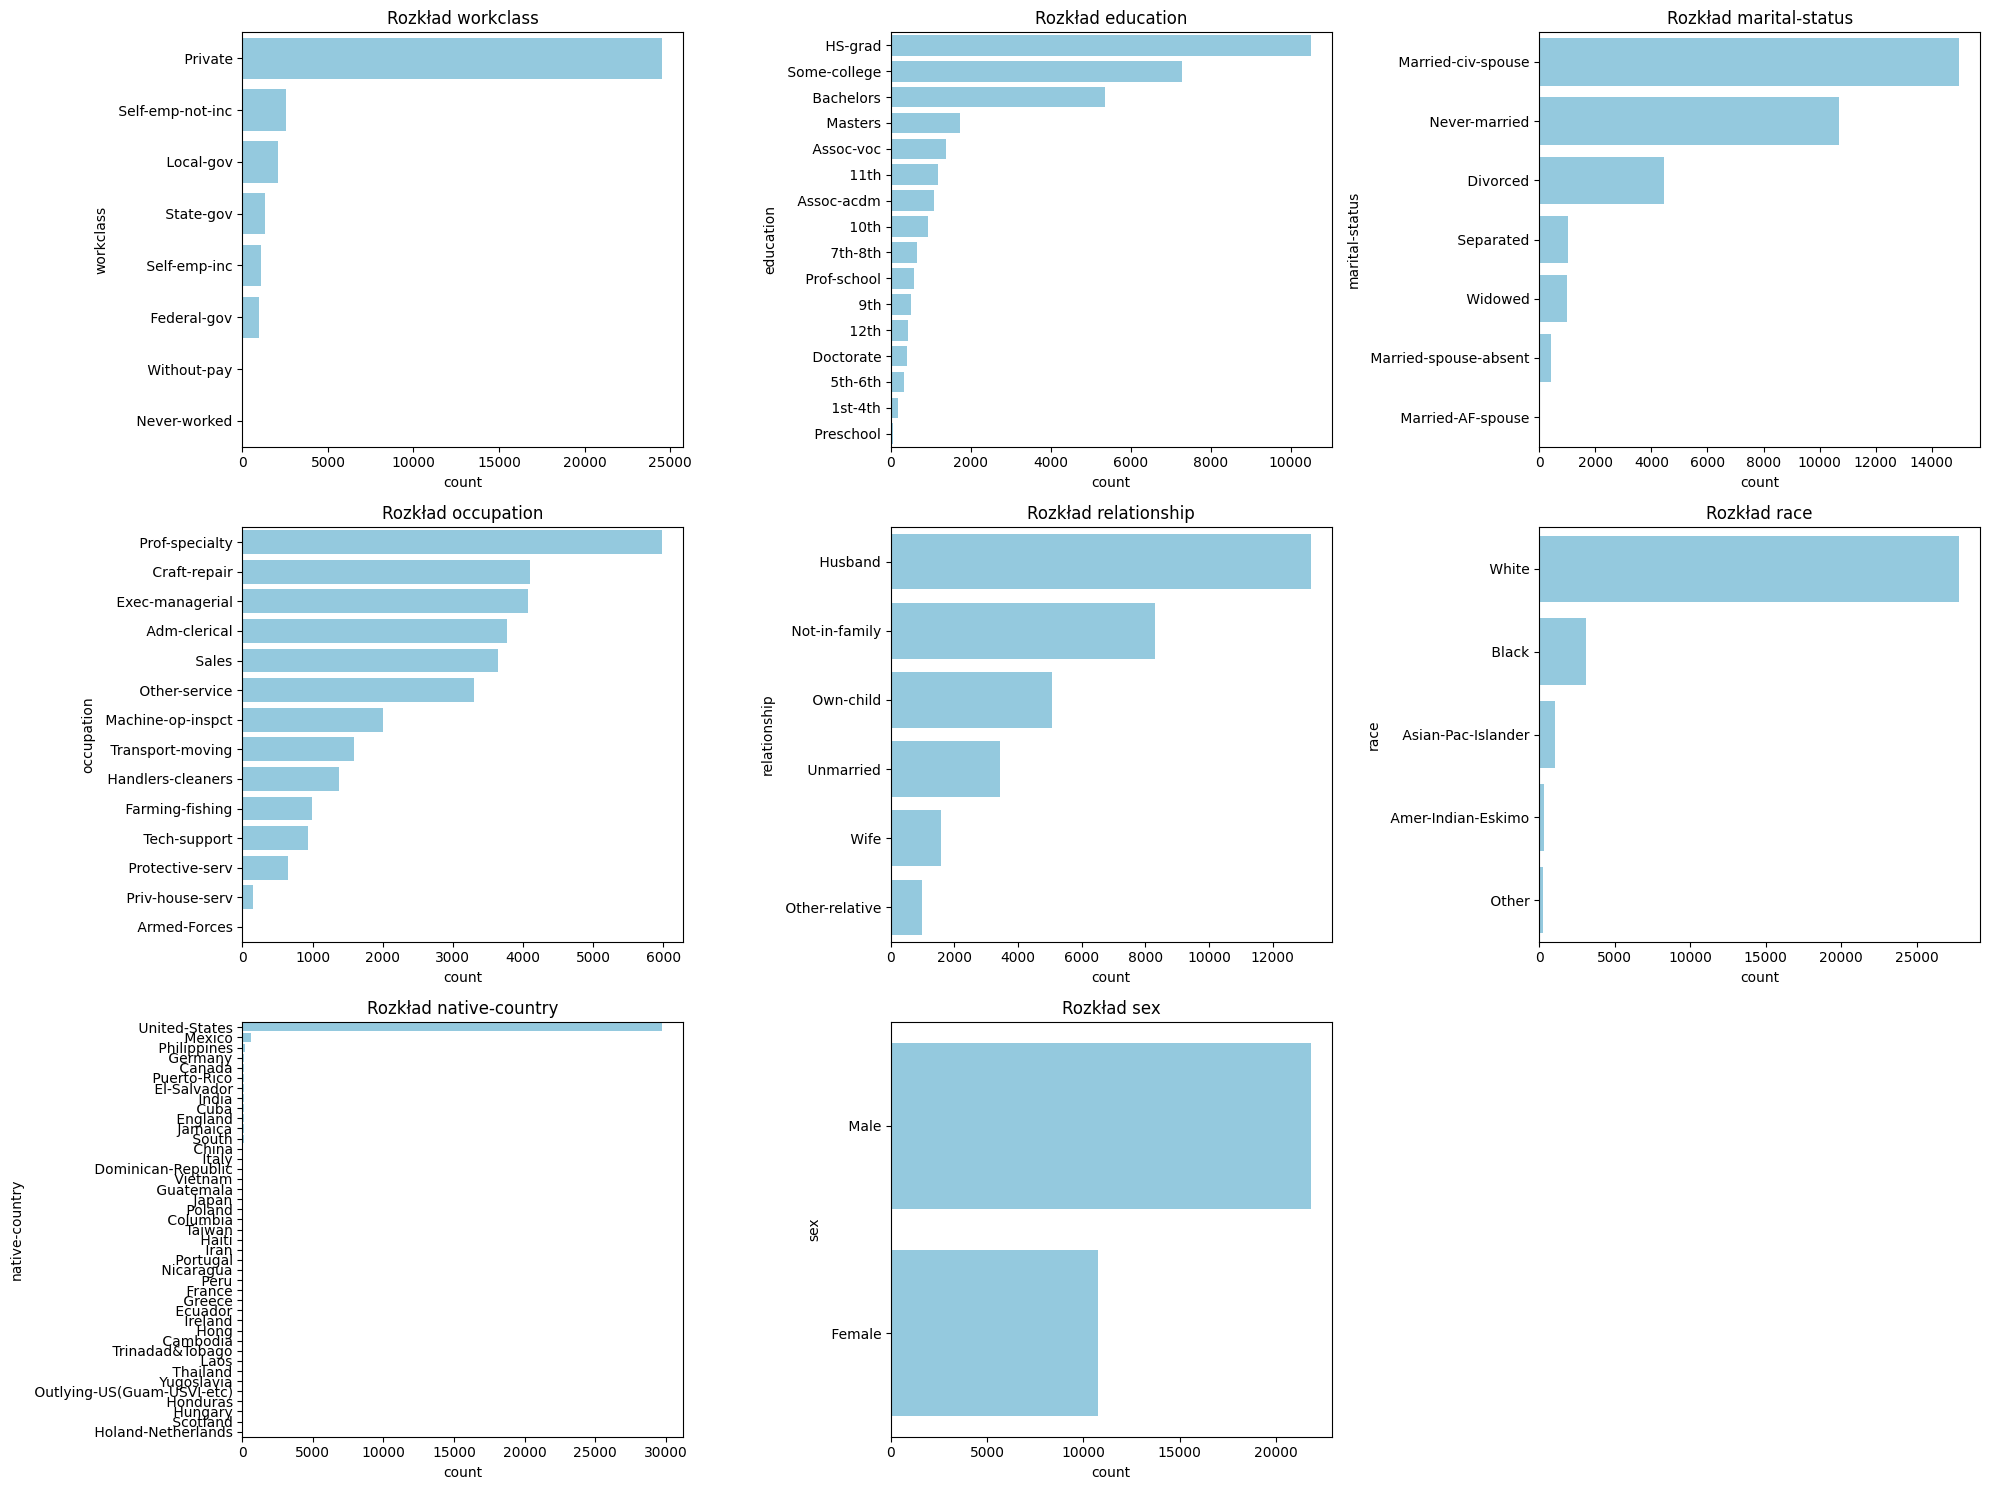

In [182]:
all_cat = cat_cols + ['sex']

plt.figure(figsize=(20,15))

for i, col in enumerate(all_cat):
    plt.subplot(3,3,i+1)
    sns.countplot(y=eda_data[col], order=eda_data[col].value_counts().index, color='skyblue')
    plt.title(f'Rozkład {col}')

plt.tight_layout()
plt.show()

Większość (prawie 2/3) pracuje w sektorze prywatnym (Private). Reszta to głównie pracownicy rządowi (federalni, stanowi, lokalni) i osoby samozatrudnione. Praktycznie nikt nie pracuje za darmo (Without-pay) albo nigdy nie pracował (Never-worked), to pojedyncze przypadki.

Najwięcej osób ma ukończoną szkołę średnią (HS-grad). Na drugim miejscu są osoby po jakimś college'u (Some-college), a na trzecim absolwenci studiów (Bachelors).

W zbiorze dominują żonaci/za mąż (Married-civ-spouse). Na drugim miejscu są single (Never-married), potem rozwiedzeni (Divorced). Inne stany (wdowy, separowani) to mniejsze grupy.

Najbardziej popularne to specjaliści (Prof-specialty), pracownicy fizyczni (Craft-repair) i menedżerowie (Exec-managerial). Są też urzędnicy, sprzedawcy, robotnicy.

Najwięcej jest mężów (Husband), potem osób niespokrewnionych (Not-in-family) i dzieci (Own-chilld).

Biali (White) stanowią ogromną większość, czarni (Black) to druga największa grupa, Azjaci i inni to mniejszości. To odzwierciedla strukturę etniczną USA w latach 90.

Stany Zjednoczone dominują absolutnie. Inne kraje to pojedyncze przypadki.

Mężczyźni stanowią większość (około 2/3), kobiety 1/3. To pewnie dlatego, że badanie dotyczyło głównie osób pracujących, a w latach 90. więcej mężczyzn było aktywnych zawodowo.

Podsumowując: Mamy typowego pracującego Amerykanina lat 90.: biały mężczyzna, żonaty, po szkole średniej, pracujący w sektorze prywatnym, urodzony w USA. Ale w danych jest też sporo różnorodności: są kobiety, samotni, ludzie z wyższym wykształceniem, imigranci, różne zawody


5.Analiza zależności zmiennych numerycznych ze zmienną docelową income

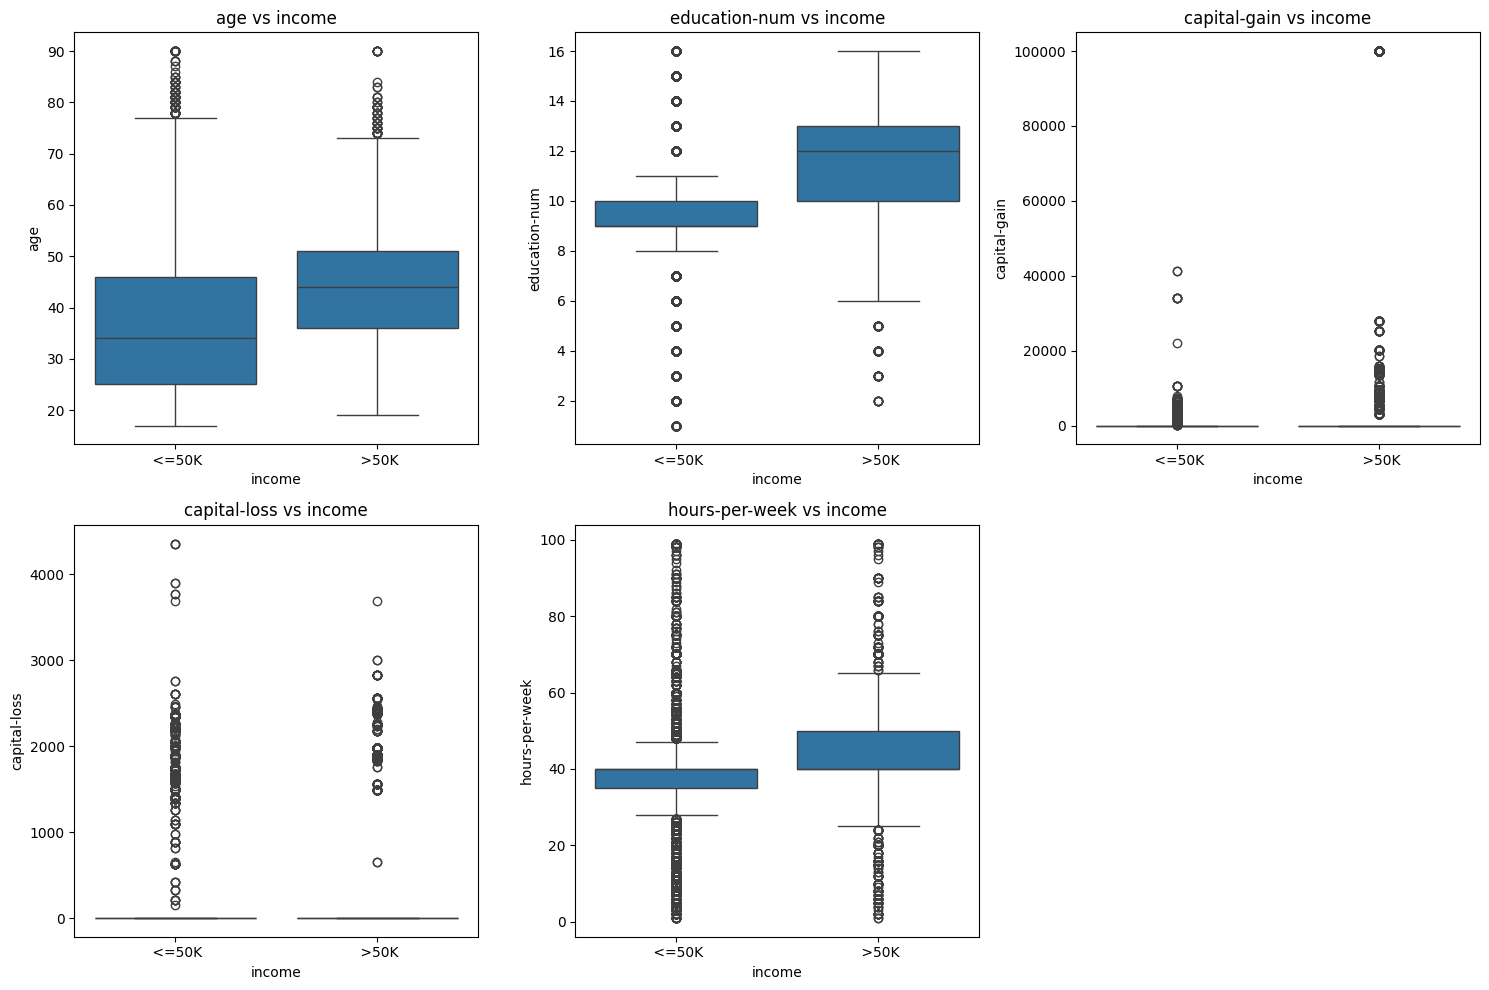

In [185]:
plt.figure(figsize=(15,10))
for i, col in enumerate(num_cols):
    plt.subplot(2,3,i+1)
    sns.boxplot(x='income', y=col, data=eda_data)
    plt.title(f'{col} vs income')
plt.tight_layout()
plt.show()


Najważniejsze czynniki przy przewidywaniu zarobków to: wiek (starszy = lepiej), wykształcenie (wyższe = lepiej) i dochody kapitałowe (jakieś > 0 = lepiej). Godziny pracy też mają znaczenie, ale mniejsze. Jeśli chcemy zgadnąć, kto zarabia dużo, patrzymy najpierw na wykształcenie i wiek, potem na to, czy ma inwestycje."

6. Analiza zależności zmiennych kategorycznych i binarnych z income

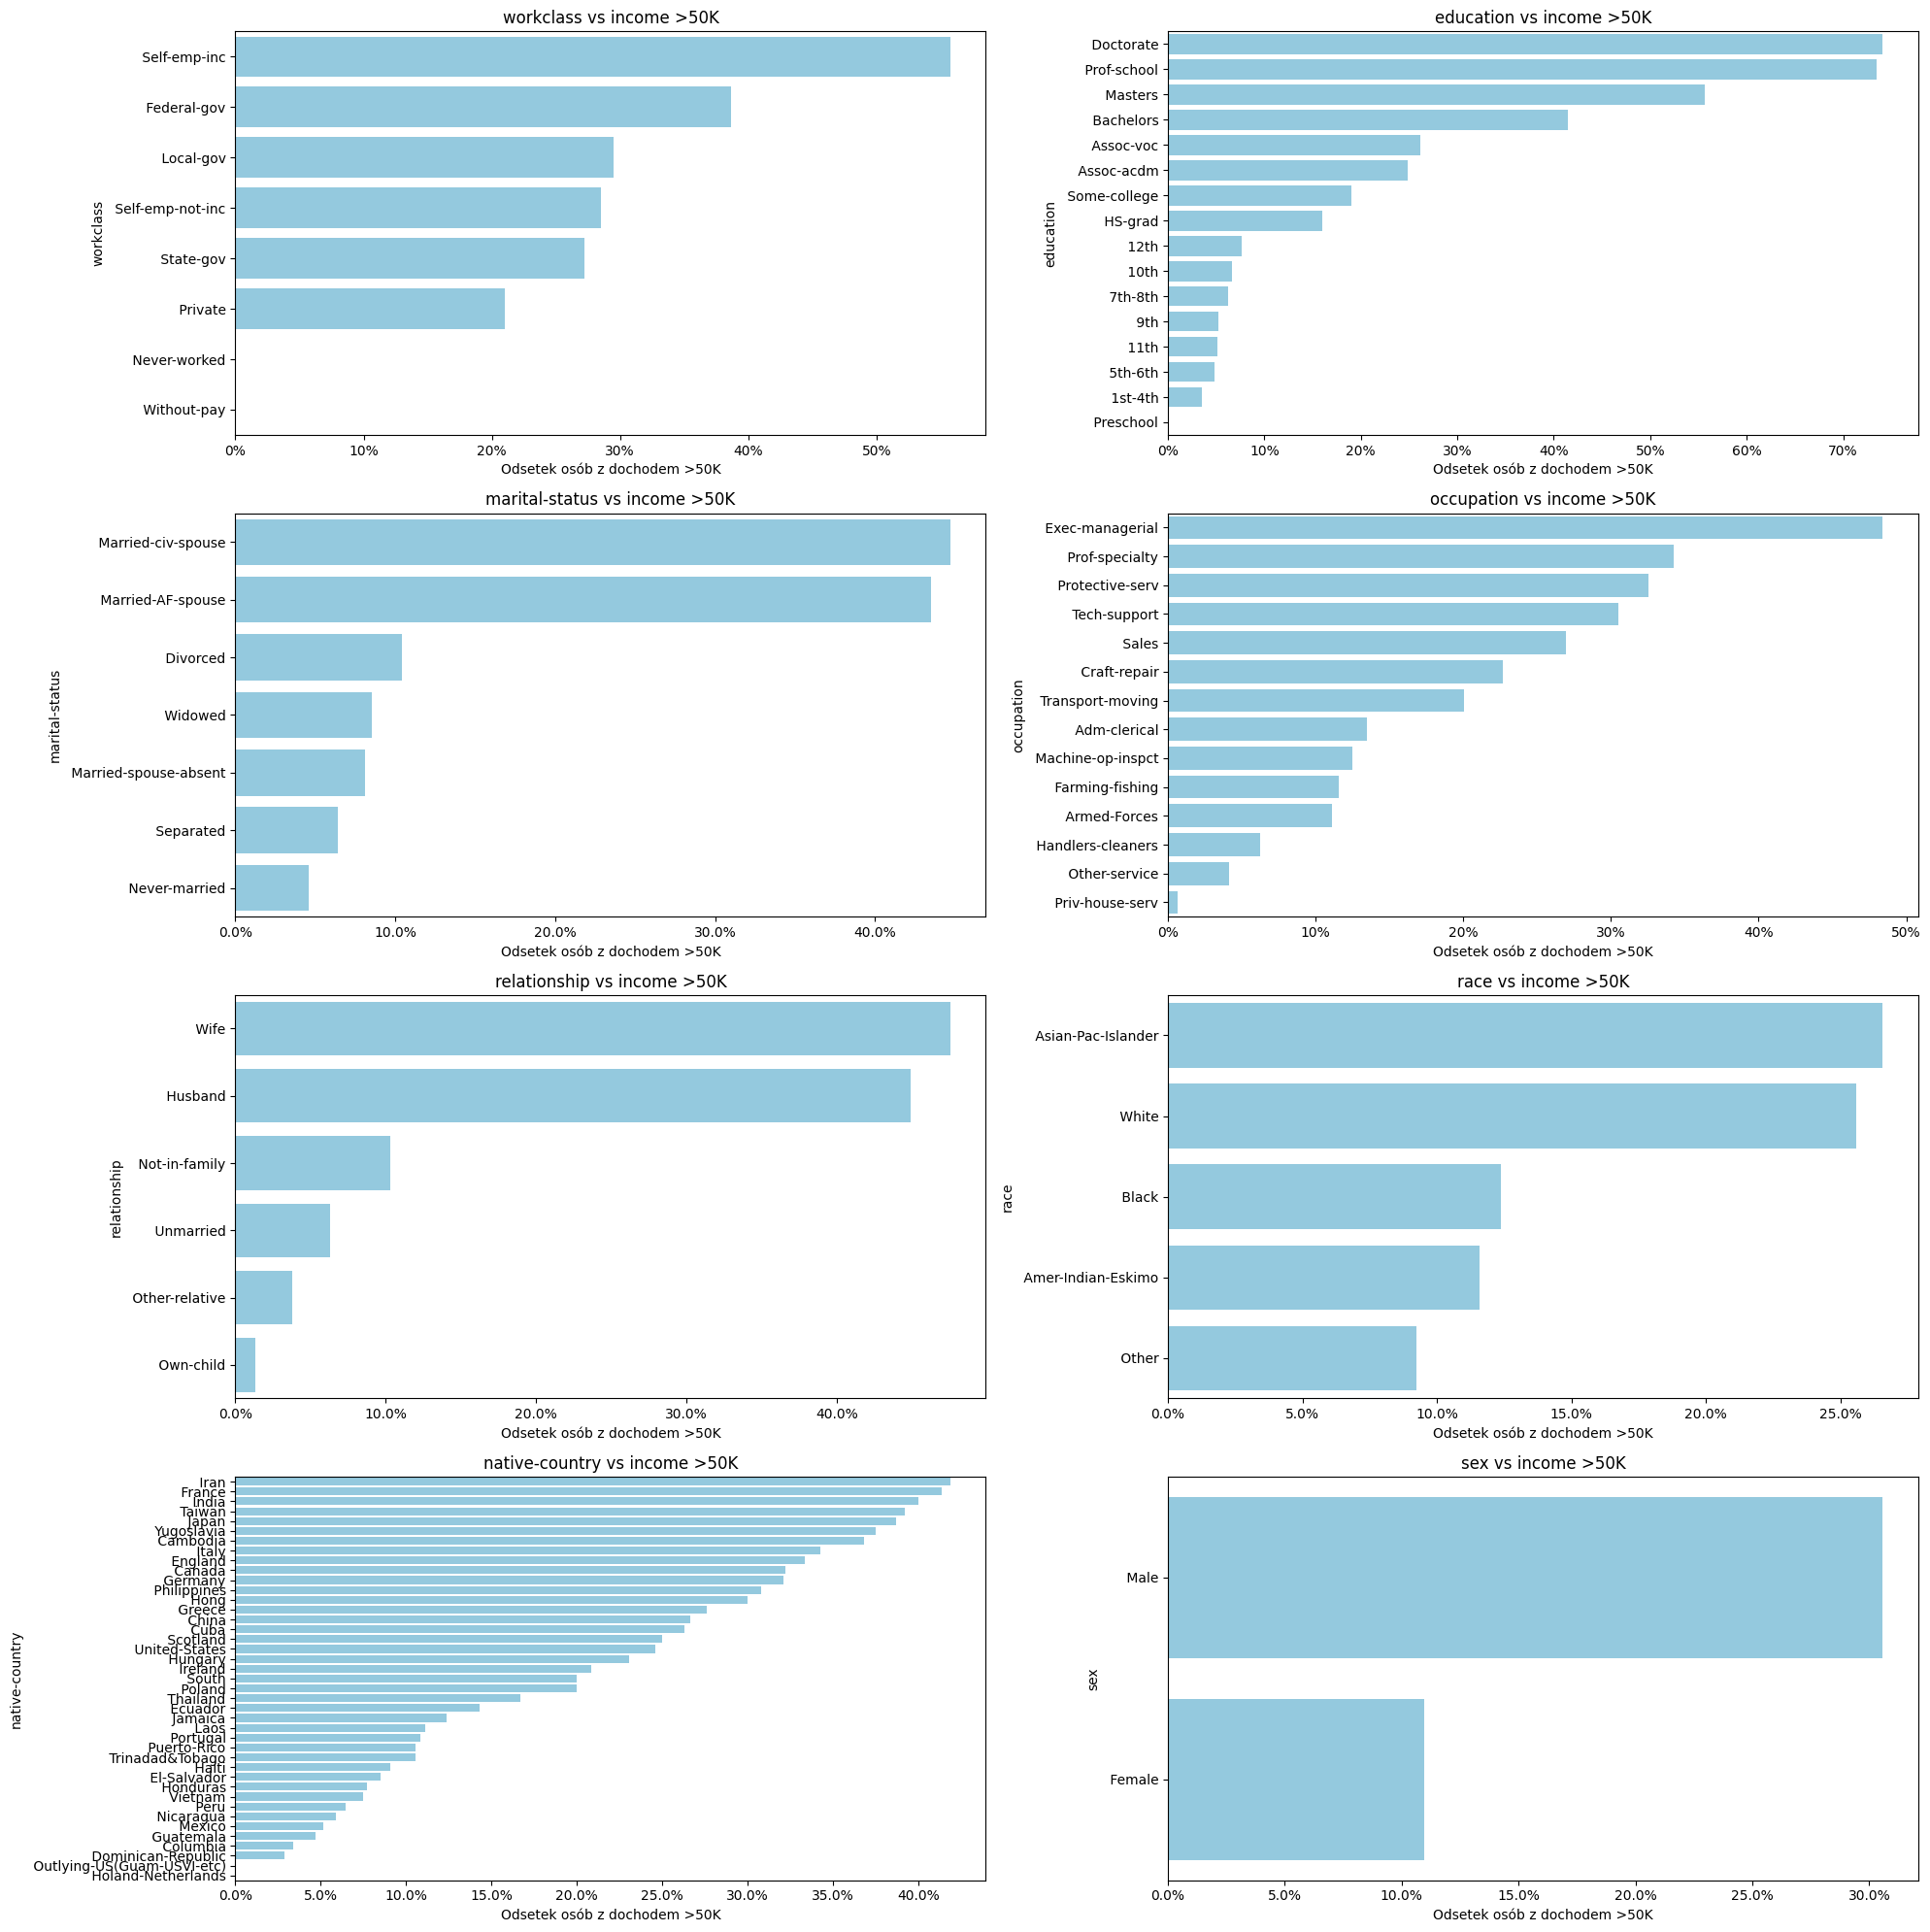

In [188]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mtick

eda_data['income'] = eda_data['income'].str.strip()

# wszystkie zmienne kategoryczne + binarna sex
cols_to_check = ['workclass', 'education', 'marital-status', 
                 'occupation', 'relationship', 'race', 'native-country', 'sex']

plt.figure(figsize=(20,20))

for i, col in enumerate(cols_to_check):
    plt.subplot(4,2,i+1)
    
    # odsetek osób z dochodem >50K w każdej kategorii
    prop = (eda_data.groupby(col)['income']
            .apply(lambda x: (x=='>50K').mean())
            .sort_values(ascending=False))
    
    # wykres słupkowy
    sns.barplot(x=prop.values, y=prop.index, color='skyblue')
    
    # format procentowy na osi x
    plt.xlabel('Odsetek osób z dochodem >50K')
    plt.gca().xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    plt.title(f'{col} vs income >50K')

plt.tight_layout()
plt.show()


Wykształcenie to najważniejszy czynnik, ponad 60% doktorów i 50% magistrów zarabia >50K vs prawie 0% osób po podstawówce.

Małżeństwo daje dużą przewagę, wśród żonatych 40% zarabia >50K vs tylko 5% singli. To pokazuje korelację między stabilizacją życiową a dochodami.

Nierówność płci jest drastyczna, mężczyźni mają 3x większą szansę na wysokie zarobki (30% vs 10% kobiet). To odzwierciedla rzeczywistość rynku pracy lat 90.

Samozatrudnienie z inkorporacją się opłaca, w tej grupie 40% zarabia >50K vs 20% wśród zwykłych pracowników prywatnych.

Zawód menedżera/specjalisty = wyższe zarobki, około 45% osób na tych stanowiskach przekracza próg 50K.

Różnice rasowe istnieją, ale są mniejsze i nie tak kluczowe jak wykształcenie czy płeć.

Ponieważ 90% osób pochodzenia USA, analiza innych krajów jest niepewna. Jedyny wiarygodny wniosek: wśród Amerykanów 20% zarabia >50K.

7.Segmentacja

Segmentacja (klastrowanie) pozwala zidentyfikować naturalne grupy osób o podobnych cechach demograficznych i ekonomicznych, bez użycia zmiennej docelowej.

In [192]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

features = eda_data[['age', 'education-num', 'hours-per-week', 'capital-gain']]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)

C:\Users\HP\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
found 0 physical cores < 1
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\HP\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 282, in _count_physical_cores
    raise ValueError(f"found {cpu_count_physical} physical cores < 1")


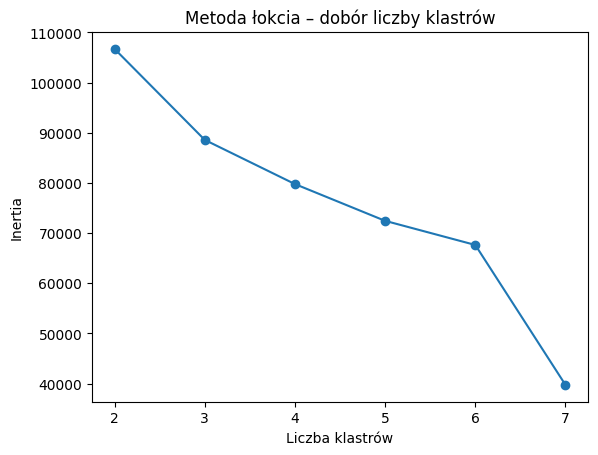

In [193]:
inertia = []

for k in range(2, 8):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(range(2, 8), inertia, marker='o')
plt.title("Metoda łokcia – dobór liczby klastrów")
plt.xlabel("Liczba klastrów")
plt.ylabel("Inertia")
plt.show()


Metoda łokcia mówi nam, że na podstawie TYLKO tych 4 cech ludzie naturalnie dzielą się na 3-4 grupy.

Klaster 1: Młodzi, słabo wykształceni, pracują mało godzin, zero zysków kapitałowych

Klaster 2: Średniego wieku, średnie wykształcenie, standardowe godziny pracy, może trochę zysków

Klaster 3: Starsze, dobrze wykształcone, dużo godzin pracy, spore zyski kapitałowe

Klaster 4: (jeśli wybierzemy 4) Może jakaś niszowa grupa, np. młodzi z dużymi zyskami (spadki/inwestycje)

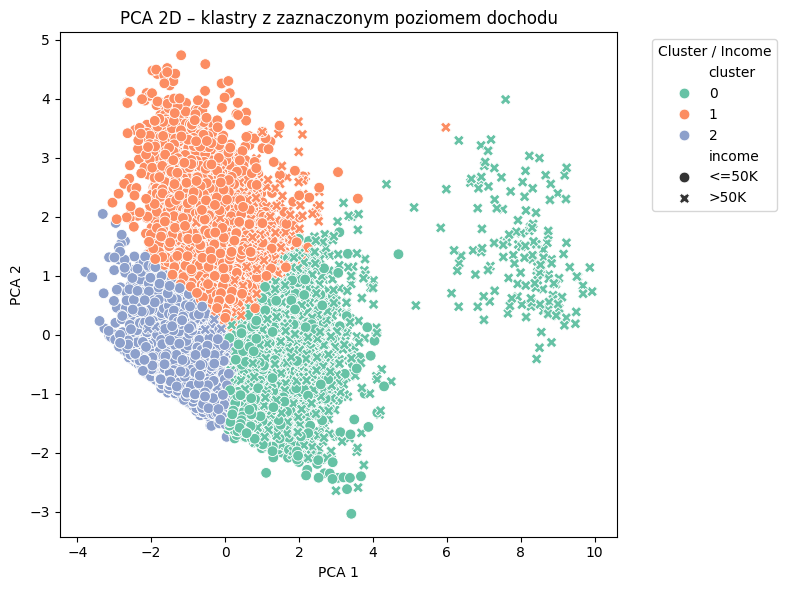

In [195]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA


features = ['age', 'education-num', 'hours-per-week', 'capital-gain']
X = eda_data[features]


scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


kmeans = KMeans(n_clusters=3, random_state=42)
eda_data['cluster'] = kmeans.fit_predict(X_scaled)


pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

eda_data['pca1'] = X_pca[:, 0]
eda_data['pca2'] = X_pca[:, 1]

plt.figure(figsize=(8,6))
sns.scatterplot(
    data=eda_data,
    x='pca1',
    y='pca2',
    hue='cluster',
    style='income',
    palette='Set2',
    s=60
)
plt.title("PCA 2D – klastry z zaznaczonym poziomem dochodu")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.legend(title='Cluster / Income', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

Przeprowadziliśmy klasteryzację K-średnich. Metoda łokcia sugerowała 3-4 klastry jako optymalne, wybrano 3. Do klasteryzacji użyliśmy standaryzowanych zmiennych numerycznych: wiek, lata edukacji, godziny pracy i zysk kapitałowy, a wyniki wizualizowaliśmy po redukcji wymiarów za pomocą PCA.
Wyniki pokazały wyraźne segmenty: jeden klaster to osoby o niskich dochodach(niebieski kolor, bo najwięcej kół), drugi o wysokich dochodach(zielony, więcej kszyżyków), a trzeci to grupa przejściowa, co potwierdza, że cechy demograficzne i zawodowe tworzą naturalne grupy o różnym potencjale dochodowym.


CZĘŚĆ 3 

Stworzenie min. 3 modeli i tuning hiperparametrów do zadania klasyfikacji

1. W celu przeprowadzenia zadania klasyfikacji konieczne było rozdzielenie przetworzonych danych na macierz cech opisujących jednostki oraz binarną zmienną docelową informującą, czy dochód przekracza próg 50 tys. USD rocznie.

In [198]:
from sklearn.model_selection import train_test_split

# X = wszystkie cechy, y = zmienna docelowa
X_train = train_data.drop('income', axis=1)
y_train = train_data['income']

X_test = test_data.drop('income', axis=1)
y_test = test_data['income']

X_train.shape, X_test.shape

((32561, 97), (16280, 97))

2. Regresja logistyczna - model bazowy, umożliwi interpretację wpływu cech na log‑szanse przynależności do klasy wysokiego dochodu

In [200]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

log_reg = LogisticRegression(max_iter=1000, solver='lbfgs')

param_grid_log = {
    'C': [0.01, 0.1, 1, 10],        # siła regularyzacji (mniejsza C = silniejsza kara)
    'penalty': ['l2']
}

grid_log = GridSearchCV(
    estimator=log_reg,
    param_grid=param_grid_log,
    scoring='f1',           # bo klasy są nierównomierne
    cv=3,
    n_jobs=-1
)

grid_log.fit(X_train, y_train)

print("Najlepsze parametry (LogReg):", grid_log.best_params_)
print("Najlepszy wynik CV (F1):", grid_log.best_score_)

Najlepsze parametry (LogReg): {'C': 1, 'penalty': 'l2'}
Najlepszy wynik CV (F1): 0.6453717709507613


3. Model random forests - jest tutaj używany jako drugi, „silniejszy” model, bo dobrze pasuje do charakteru danych Adult i uzupełnia regresję logistyczną. Potrafi uchwycić złożone, nieliniowe zależności oraz interakcje między cechami (np. konkretne kombinacje wieku, wykształcenia i godzin pracy). Jest stosunkowo odporny na przeuczenie, a jednocześnie w praktyce często osiąga wyższą skuteczność klasyfikacji na danych tablicowych, takich jak zbiór Adult.

In [202]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)

param_grid_rf = {
    'n_estimators': [100, 200],      # liczba drzew
    'max_depth': [None, 10, 20],     # maksymalna głębokość drzewa
    'min_samples_split': [2, 10],    # minimalna liczba próbek do podziału
    'min_samples_leaf': [1, 4]       # minimalna liczba próbek w liściu
}

grid_rf = GridSearchCV(
    estimator=rf,
    param_grid=param_grid_rf,
    scoring='f1',
    cv=3,
    n_jobs=-1
)

grid_rf.fit(X_train, y_train)

print("Najlepsze parametry (RF):", grid_rf.best_params_)
print("Najlepszy wynik CV (F1):", grid_rf.best_score_)

Najlepsze parametry (RF): {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 200}
Najlepszy wynik CV (F1): 0.6852873791904828


4. Model HistGradientBoostingClassifier - implementuje gradient boosting drzew decyzyjnych, w którym kolejne płytkie drzewa są dodawane sekwencyjnie, aby stopniowo korygować błędy poprzednich; dzięki temu algorytm dobrze odwzorowuje złożone, nieliniowe relacje w danych tablicowych.

In [204]:
from sklearn.ensemble import HistGradientBoostingClassifier

hgb = HistGradientBoostingClassifier(random_state=42)

param_grid_hgb = {
    'learning_rate': [0.05, 0.1],
    'max_depth': [None, 6, 10],
    'max_iter': [100, 200]
}

grid_hgb = GridSearchCV(
    estimator=hgb,
    param_grid=param_grid_hgb,
    scoring='f1',
    cv=3,
    n_jobs=-1
)

grid_hgb.fit(X_train, y_train)

print("Najlepsze parametry (HGB):", grid_hgb.best_params_)
print("Najlepszy wynik CV (F1):", grid_hgb.best_score_)

Najlepsze parametry (HGB): {'learning_rate': 0.1, 'max_depth': 6, 'max_iter': 200}
Najlepszy wynik CV (F1): 0.709817648764667


5. Ocena modeli na zbiorze testowym

In [206]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

best_log = grid_log.best_estimator_
best_rf = grid_rf.best_estimator_
best_hgb = grid_hgb.best_estimator_

models = {
    'Logistic Regression': best_log,
    'Random Forest': best_rf,
    'HistGradientBoosting': best_hgb
}

results = []

for name, model in models.items():
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else model.decision_function(X_test)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba)

    results.append([name, acc, prec, rec, f1, auc])

results_df = pd.DataFrame(results, columns=['Model', 'Accuracy', 'Precision', 'Recall', 'F1', 'ROC AUC'])
results_df

,Model,Accuracy,Precision,Recall,F1,ROC AUC
0,Logistic Regression,0.845885,0.714332,0.579303,0.639770,0.898191
1,Random Forest,0.860872,0.752960,0.611804,0.675082,0.910977
2,HistGradientBoosting,0.872236,0.776110,0.645346,0.704713,0.926756


Wyraźna przewaga algorytmów zespołowych nad regresją logistyczną. Boosting drzew decyzyjnych najskuteczniej uchwycił złożone, nieliniowe zależności między cechami a dochodem, co czyni go najbardziej odpowiednim modelem dla analizowanego zadania klasyfikacyjnego.

In [208]:
results_df.to_excel("wyniki_modeli.xlsx", index=False)

5.1. Krzywe ROC

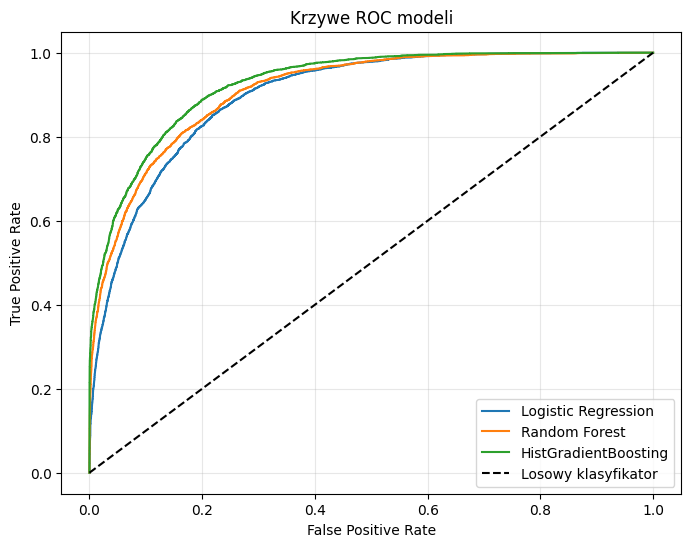

In [210]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

for name, model in models.items():
    y_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else model.decision_function(X_test)
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    plt.plot(fpr, tpr, label=name)

plt.plot([0, 1], [0, 1], 'k--', label='Losowy klasyfikator')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Krzywe ROC modeli')
plt.legend()
plt.grid(alpha=0.3)
plt.show()


Krzywa ROC pokazuje kompromis między czułością (TPR) a odsetkiem fałszywych alarmów (FPR) dla różnych progów. Widzimy na wykresie, ze Boosting drzew decyzyjnych jest najlepszym modelem.

5.2. Macierze pomyłek

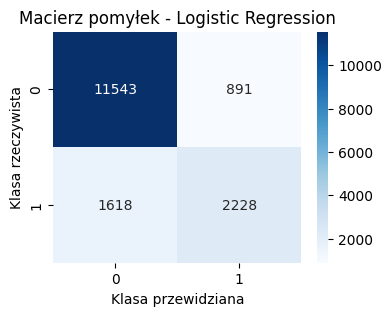

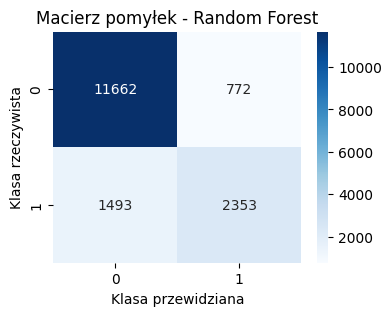

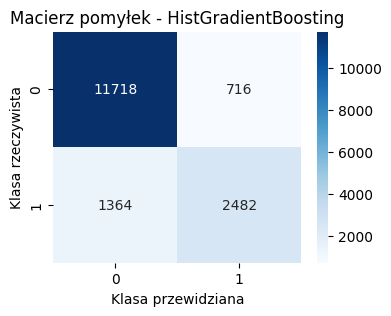

In [213]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

for name, model in models.items():
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(4, 3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Macierz pomyłek - {name}')
    plt.xlabel('Klasa przewidziana')
    plt.ylabel('Klasa rzeczywista')
    plt.show()

Analiza macierzy pomyłek pokazuje, że regresja logistyczna generuje relatywnie dużo błędów typu FN, czyli przypadków błędnego zaklasyfikowania osób o dochodach >50K do klasy niższego dochodu. Zastosowanie lasu losowego zmniejsza zarówno liczbę FP, jak i FN, co przekłada się na wyższą precyzję i czułość. Najlepsze wyniki uzyskuje jednak model HistGradientBoostingClassifier, który charakteryzuje się najniższą liczbą obu typów błędów, co jest spójne z najwyższymi wartościami F1 oraz ROC AUC odnotowanymi dla tego modelu.

6. Podsumowanie
   
W trakcie realizacji projektu przeprowadzono kompletny proces analizy danych, obejmujący wczytanie i wstępne rozpoznanie zbioru Adult, czyszczenie i przetwarzanie danych, analizę eksploracyjną (EDA), budowę oraz strojenie modeli klasyfikacyjnych, a następnie ich porównanie i wybór najlepszego rozwiązania. Celem było przewidywanie, czy dochód danej osoby przekracza 50 000 USD rocznie, co stanowi klasyczny problem klasyfikacji binarnej.

Porównanie wyników trzech modeli wykazało wyraźną zależność pomiędzy złożonością algorytmu a jakością predykcji. Regresja logistyczna, jako model bazowy, osiągnęła najsłabsze wyniki, co wynika z jej liniowego charakteru i ograniczonej zdolności do modelowania nieliniowych zależności oraz interakcji pomiędzy cechami. Random Forest wyraźnie poprawił skuteczność klasyfikacji, zwłaszcza w zakresie wykrywania klasy >50K, dzięki możliwości uchwycenia złożonych relacji i progów decyzyjnych. Najlepsze wyniki uzyskano jednak dla modelu HistGradientBoosting, który osiągnął najwyższe wartości F1-score oraz ROC-AUC, a jego macierz pomyłek charakteryzowała się największą liczbą poprawnych predykcji dla klasy wysokiego dochodu przy jednoczesnym ograniczeniu liczby błędów.

Jednym z głównych problemów napotkanych w projekcie była jakość danych. W zbiorze Adult występują braki danych oznaczone symbolem „?”, które nie są automatycznie rozpoznawane jako wartości brakujące przez bibliotekę Pandas. Konieczne było ich ręczne zastąpienie wartościami NaN, a następnie zastosowanie imputacji. Dla zmiennych numerycznych użyto mediany, odpornej na wartości odstające, natomiast dla zmiennych kategorycznych, najczęściej występującej wartości (mody). Rozwiązanie to pozwoliło zachować wszystkie obserwacje w zbiorze i uniknąć strat informacyjnych wynikających z usuwania rekordów.

Kolejnym wyzwaniem była obecność dużej liczby zmiennych kategorycznych. Zastosowanie kodowania one-hot znacząco zwiększyło liczbę cech, co prowadziło do wzrostu wymiarowości danych. Mimo to było to konieczne, aby umożliwić wykorzystanie klasycznych algorytmów uczenia maszynowego.

Istotnym problemem była również nierównowaga klas. Liczba obserwacji z dochodem ≤50K była znacznie większa niż liczba przypadków >50K. Z tego względu sama miara accuracy nie była wystarczająca do rzetelnej oceny jakości modeli. Zastosowano więc miary F1-score oraz ROC-AUC, które lepiej odzwierciedlają skuteczność klasyfikacji w warunkach niezbalansowanych danych. 

Dodatkowym wyzwaniem były wartości odstające w zmiennych takich jak capital-gain, capital-loss czy hours-per-week. Zastosowano transformację logarytmiczną, która zmniejszyła skośność rozkładów i ograniczyła wpływ ekstremalnych wartości na proces uczenia modeli, szczególnie tych o charakterze liniowym.

Podsumowując, projekt pokazał, jak duże znaczenie w zadaniach uczenia maszynowego ma nie tylko wybór algorytmu, ale przede wszystkim odpowiednie przygotowanie danych oraz właściwa procedura walidacji i strojenia parametrów. Najlepsze rezultaty uzyskał model HistGradientBoosting, który dzięki swojej zdolności do modelowania złożonych, nieliniowych zależności i interakcji między cechami najlepiej dopasował się do charakteru zbioru Adult. Model ten został wybrany jako rozwiązanie końcowe, ponieważ zapewnił najwyższą skuteczność predykcji oraz najbardziej korzystny kompromis pomiędzy precyzją, czułością i stabilnością wyników.